# Airbnb Price Prediction - Exploratory Data Analysis

## Objective
Understand key factors that influence Airbnb listing prices using data PostgreSQL/CSV.

The project uses:
- PostgreSQL for data storage
- Pandas for analysis
- Scikit-learn for preprocessing and modeling
- Random Forest Regression for prediction

Goals of analysis:
1. Understand pricing trends
2. Identify important features
3. Examine missing values
4. Justify preprocessing decisions for modeling

In [99]:
import sys
import pandas as pd
import os
from pathlib import Path

#sys.path.append(str(Path().resolve().parent))

In [103]:
from pathlib import Path
import pandas as pd

NOTEBOOK_DIR = Path().resolve()

PROJECT_ROOT = NOTEBOOK_DIR

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

data_path = PROJECT_ROOT/"data"/"listings.csv"

df = pd.read_csv(data_path)

print(df.shape)
df.head()

(33457, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,5269,https://www.airbnb.com/rooms/5269,20250916040722,2025-09-16,city scrape,Upcountry Hospitality in the 'Auwai Suite,"The 'Auwai Suite is a lovely, self-contained a...","We are located on the ""sunny side"" of Waimea, ...",https://a0.muscache.com/pictures/5b52b72f-5a09...,7620,...,4.87,5.00,4.87,119-269-5808-01R,f,3,3,0,0,0.26
1,5387,https://www.airbnb.com/rooms/5387,20250916040722,2025-09-16,city scrape,Hale Koa Studio & 1 Bedroom Units!!,This Wonderful Spacious Studio apt/flat is in ...,IN a Farm belt area with small commercial farm...,https://a0.muscache.com/pictures/1170713/dca6a...,7878,...,4.88,4.75,4.78,TA-163-133-0304-01,t,2,2,0,0,1.24
2,5480,https://www.airbnb.com/rooms/5480,20250916040722,2025-09-16,city scrape,Isle Of You Naturally Farm Retreat,The Best Choice for your Clothing Optional Nud...,We are located on a rural one lane road going ...,https://a0.muscache.com/pictures/75530989/8ed3...,8145,...,NaN,NaN,NaN,NaN,f,3,0,3,0,NaN
3,7896,https://www.airbnb.com/rooms/7896,20250916040722,2025-09-17,city scrape,"Maui Sunset Condo Beachfront Resort, Kihei/Wailea",GREAT VALUE ON THE BEACH! <br />Remodeled (May...,Conveniently located to all the sights on the ...,https://a0.muscache.com/pictures/26282/e86e740...,21844,...,4.93,4.85,4.61,"390010020007, TA-169-914-3680-01",f,1,1,0,0,0.53
4,13238,https://www.airbnb.com/rooms/13238,20250916040722,2025-09-17,city scrape,Studio On Princeville Golf Course / Paniolo Condo,Our place is in the Princeville Resort facing ...,Located in Princeville Resort. Beautiful Homes...,https://a0.muscache.com/pictures/0472d143-241b...,51647,...,4.76,4.79,4.53,"540050030025, TA-095-127-9616-01",f,2,2,0,0,1.43


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33457 entries, 0 to 33456
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            33457 non-null  int64  
 1   listing_url                                   33457 non-null  object 
 2   scrape_id                                     33457 non-null  int64  
 3   last_scraped                                  33457 non-null  object 
 4   source                                        33457 non-null  object 
 5   name                                          33457 non-null  object 
 6   description                                   32447 non-null  object 
 7   neighborhood_overview                         16427 non-null  object 
 8   picture_url                                   33457 non-null  object 
 9   host_id                                       33457 non-null 

In [28]:
df.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.345700e+04,3.345700e+04,3.345700e+04,33455.000000,33455.000000,33457.000000,33457.000000,33457.000000,33454.000000,33389.000000,...,26727.000000,26727.000000,26727.000000,26727.000000,26727.000000,33457.000000,33457.000000,33457.000000,33457.000000,26731.000000
mean,6.104404e+17,2.025092e+13,1.972884e+08,230.119265,339.385862,20.907427,-157.213037,4.835311,1.657156,1.618228,...,4.774564,4.857064,4.843942,4.874131,4.692095,91.814538,89.533252,1.580506,0.006546,1.132746
std,5.588202e+17,7.734491e+00,1.899530e+08,581.161037,981.321176,0.813627,1.289815,2.517304,0.998055,1.244691,...,0.332101,0.286762,0.308554,0.229185,0.363737,135.730856,135.797158,6.821618,0.163245,1.276851
min,5.269000e+03,2.025092e+13,8.840000e+02,1.000000,1.000000,18.989648,-159.716528,1.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,4.075260e+07,2.025092e+13,3.907322e+07,3.000000,4.000000,20.686770,-157.839390,4.000000,1.000000,1.000000,...,4.700000,4.840000,4.820000,4.840000,4.600000,2.000000,2.000000,0.000000,0.000000,0.220000
50%,6.999813e+17,2.025092e+13,1.161647e+08,33.000000,42.000000,20.958180,-156.691080,4.000000,1.000000,1.000000,...,4.870000,4.940000,4.940000,4.930000,4.770000,25.000000,20.000000,0.000000,0.000000,0.650000
75%,1.130242e+18,2.025092e+13,3.733074e+08,242.000000,301.000000,21.309290,-156.366140,6.000000,2.000000,2.000000,...,5.000000,5.000000,5.000000,5.000000,4.900000,126.000000,121.000000,0.000000,0.000000,1.690000
max,1.510558e+18,2.025092e+13,7.183320e+08,3898.000000,9683.000000,22.229090,-154.842280,16.000000,14.000000,48.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,540.000000,533.000000,70.000000,8.000000,23.570000


### Clean Price Column

In [32]:
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
)
df["price"] = pd.to_numeric(df["price"], errors = "coerce")

print(df["price"].isnull().sum())

325


## Price Distribution

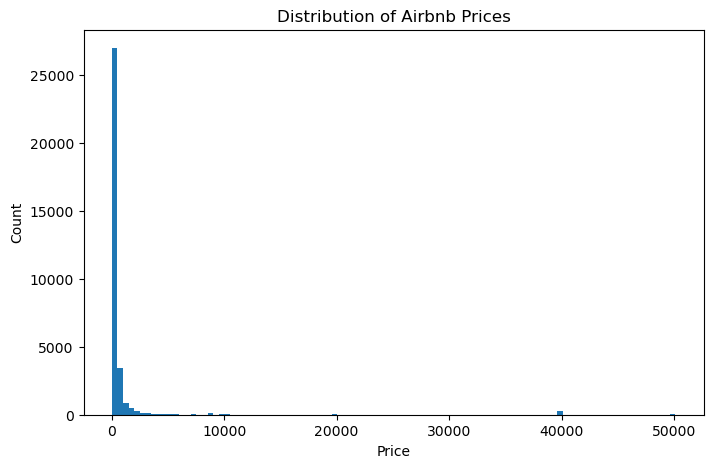

In [50]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=100)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

The distribution of Airbnb prices is heavily right-skewed.
This suggests that the mean price is not a reliable measure of price tendency due to the presence of highly priced outliers.

# Log Transformation of Price

A log transformation was applied to the price variable to reduce skew and stabilize the variance.

In [52]:
df = df.dropna(subset=["price"])

df["log_price"] = np.log1p(df["price"])

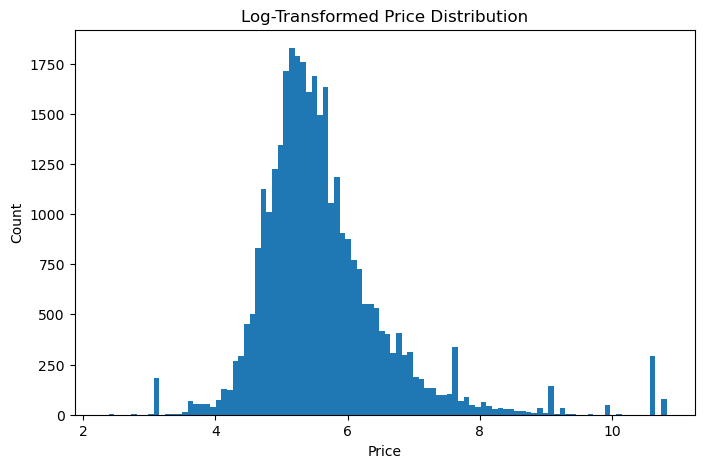

In [54]:
plt.figure(figsize=(8,5))
plt.hist(df["log_price"], bins=100)
plt.title("Log-Transformed Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

After applying the log transformation, the price distribution becomes much more normalized.
This transformation improves model performance by reducing the influence of extreme values.

## Feature Selection

For this analysis, I chose the following features based on their relevance to Airbnb pricing:

### Numeric Features
- **accomodates:** number of guests a listing can host
- bathrooms, bedrooms, beds
- **reviews_scores_rating:** listing quality
- **number_of_reviews:** popularity
- **availability_365:** listing availability throughout the year
- **latitude, longitude:** geographic location

### Categorical Features
- **room_type:** type of accomodation (entire home, private room, etc.)
- **neighbourhood_cleansed:** neighborhood location grouping

In [56]:
numeric_features = [
    "accommodates",
    "bathrooms",
    "beds",
    "bedrooms",
    "review_scores_rating",
    "number_of_reviews",
    "availability_365",
    "latitude",
    "longitude"
]

categorical_features = [
    "room_type",
    "neighbourhood_cleansed"
]

In [59]:
all_features = numeric_features + categorical_features

### Relationship between Numeric Features and Price

This section explores how each numeric feature relates to listing price (log-transformed)

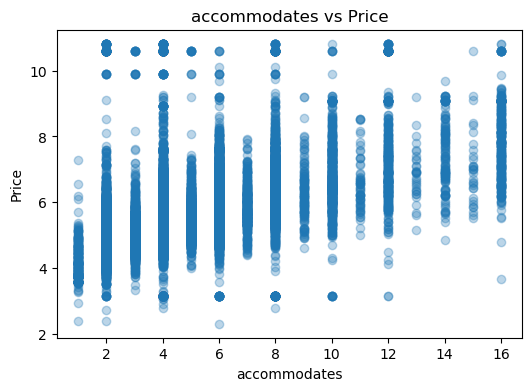

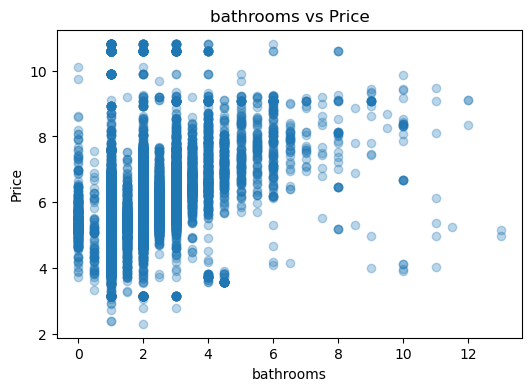

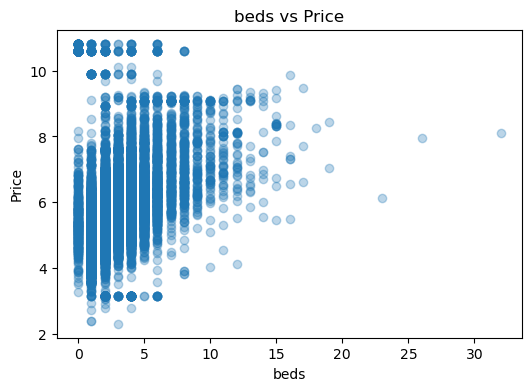

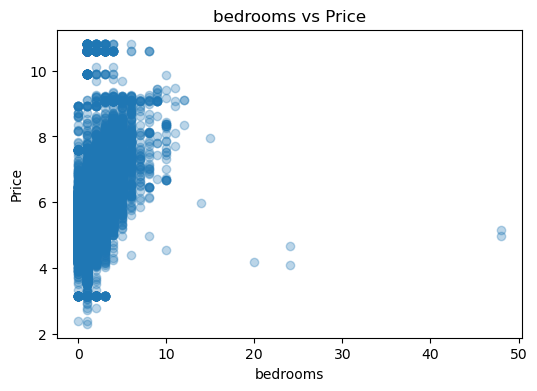

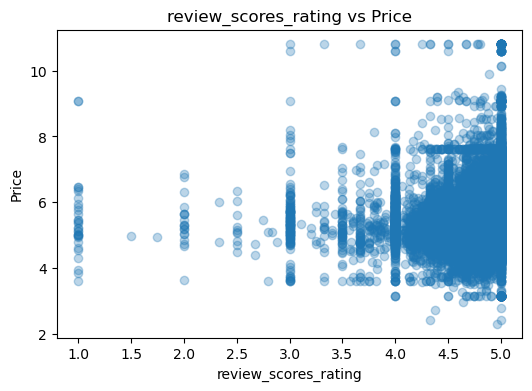

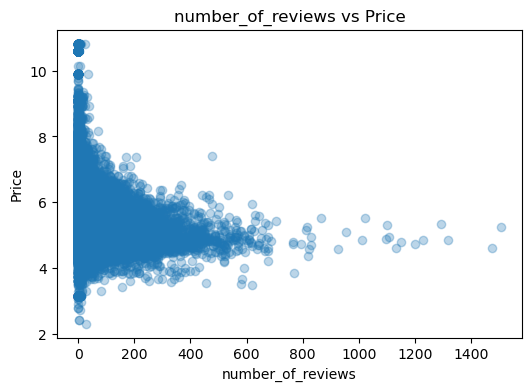

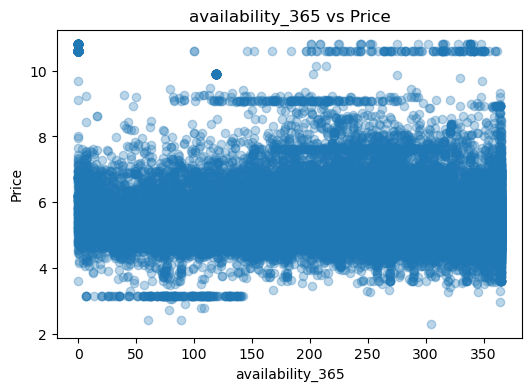

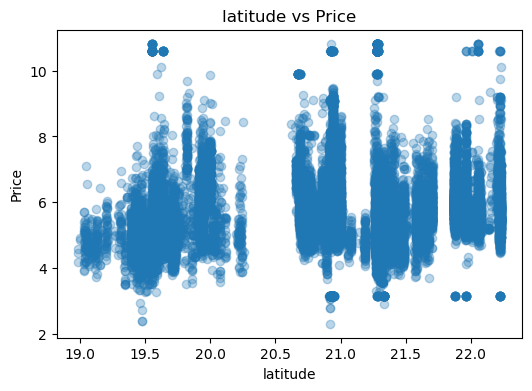

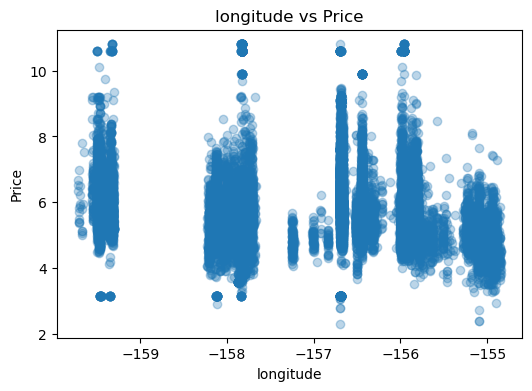

In [61]:
for col in numeric_features:
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df["log_price"], alpha=0.3)
    plt.title(f"{col} vs Price")
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.show()

Several features (like accomodates, bedrooms, bathrooms) show a positive relationship with price

Location features (lat and long) show more complex patterns, indicating that geographic effects are important but not strictly linear

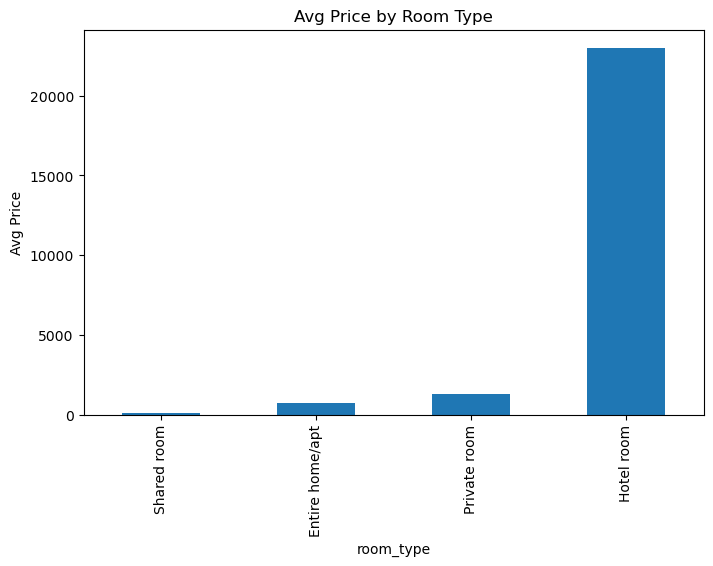

In [66]:
df.groupby("room_type")["price"].mean().sort_values().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Avg Price by Room Type")
plt.ylabel("Avg Price")
plt.show()

## Neighborhood Pricing Differences

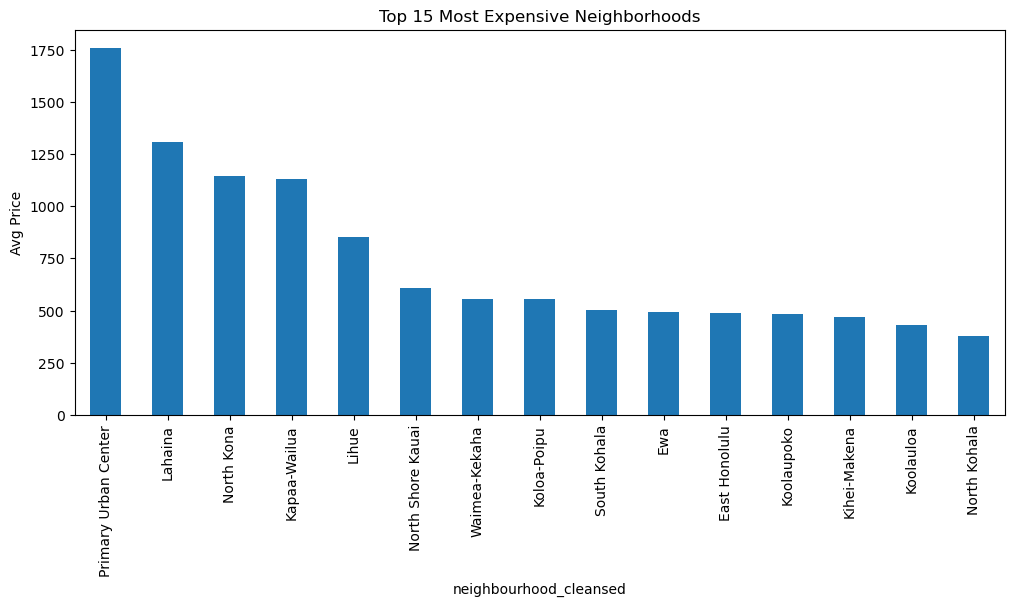

In [69]:
top_neighborhoods = (
    df.groupby("neighbourhood_cleansed")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
top_neighborhoods.plot(kind="bar", figsize=(12,5))

plt.title("Top 15 Most Expensive Neighborhoods")
plt.ylabel("Avg Price")
plt.show()

Certain neighborhoods (Urban Primary Center, Lahaina, and Norh Kona) consistently command higher prices. This indicates that geographic location is one of the strongest drivers of Airbnb pricing.

After doing some research, Urban Primary Center (where the avg price is significantly higher than the next highest) encompasses Honolulu and a large portion of O'ahu, which is the most popular tourist destination in Hawaii.

## Correlation Analysis

This correlation matrix shows relationships between numeric features and log-transformed price.

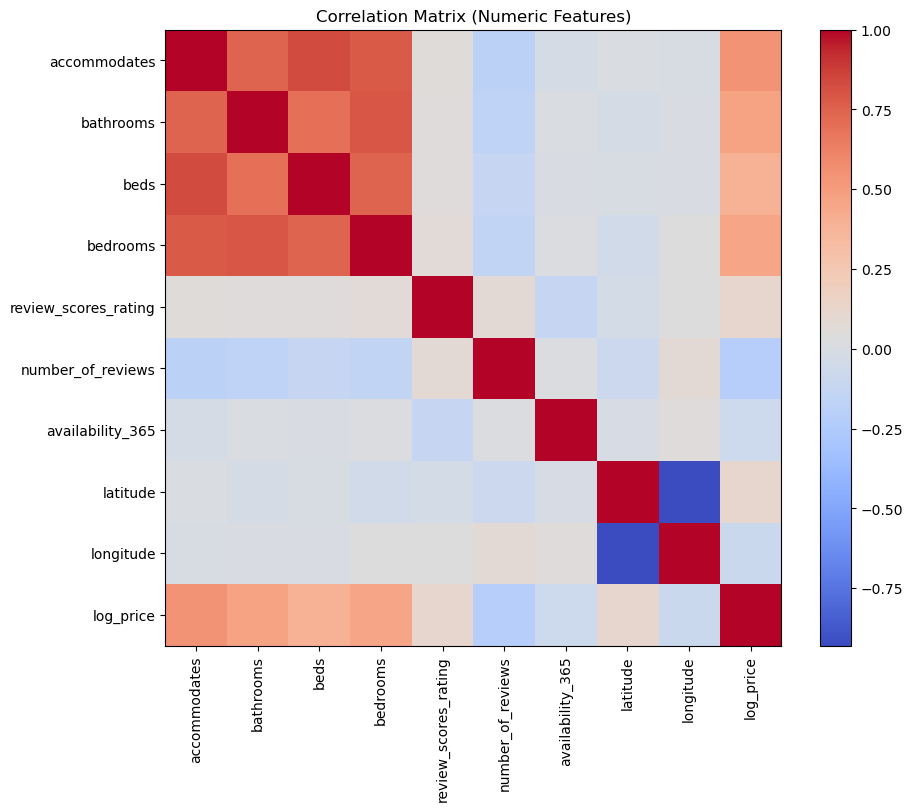

In [74]:
corr = df[numeric_features + ["log_price"]].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()
plt.title("Correlation Matrix (Numeric Features)")
plt.show()